# Support Vector Machine (SVM) From Scratch

A **Support Vector Machine** is a classifier that tries to find the best possible line (called a **hyperplane**) that separates two classes of data.

Instead of picking just *any* line that separates the classes, SVM picks the one that stays as far as possible from the closest points of each class. This distance is called the **margin**, and the points that lie closest to the hyperplane (the ones that "hold up" the margin) are called the **support vectors**.

The animation below shows the separating line and margin gradually adjusting during training on our actual dataset, ending with the support vectors highlighted in green.

![SVM Animation](../GIF/svm.gif)


## 1. Load and Explore the Data

Let's load the dataset and take a first look at it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../Data_SET/Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [3]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:

df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

**About the dataset:** each row represents a user of a social network.
- **Input features:** `Age` and `EstimatedSalary`.
- **Target variable:** `Purchased` — whether the user purchased the advertised product (1) or not (0).
- This is a **binary classification** problem with two classes: `0` (did not purchase) and `1` (purchased).


## 2. Select Features and Target

We'll use `Age` and `EstimatedSalary` as input features and `Purchased` as the target.

SVM works with labels **-1** and **+1** (not 0 and 1), so we convert the target accordingly.

In [ ]:
X = df[['Age', 'EstimatedSalary']].values.astype(float)
y = df['Purchased'].values.astype(float)


y = np.where(y == 0, -1, 1)

print("Features shape:", X.shape)
print("Labels:", np.unique(y))

Features shape: (400, 2)
Labels: [-1  1]


## 3. Train/Test Split (Manual)

We shuffle the data and split it into 80% training and 20% testing, using only NumPy.

In [6]:
np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


## 4. Feature Scaling (Manual)

We standardize the features: `X_scaled = (X - mean) / std`.

This matters a lot for SVM: the margin is a **distance**, and if one feature (like `EstimatedSalary`, which ranges in the thousands) has a much larger scale than another (like `Age`), it will dominate the distance calculation and distort the hyperplane. Scaling puts both features on equal footing.

In [7]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std  # use training stats to scale test data

X_train_scaled[:5]

array([[ 0.7703268 , -1.40084464],
       [ 1.98694012,  0.51782195],
       [-0.91421472, -0.76128911],
       [ 0.95749808,  0.7503876 ],
       [-0.82062908, -1.22642041]])

## 5. The Math Behind SVM

- **Hyperplane:** the decision boundary is `f(x) = w·x + b`. The predicted class is the **sign** of `f(x)`: `+1` or `-1`.

- **Margin:** the distance between the hyperplane and the closest points of each class. SVM tries to make this margin as wide as possible.

- **Hinge Loss:** penalizes points that fall on the wrong side of the margin:

  `L = max(0, 1 - y_i * (w·x_i + b))`

  If a point is correctly classified *and* outside the margin, its loss is 0.

- **Regularization:** we add a term `λ‖w‖²` to the loss. This keeps `w` small, which widens the margin. It balances a wide margin against classification mistakes.

- **Gradient Descent:** since a point only contributes to the loss when it violates the margin, the update rule has two cases:
  - If `y_i * (w·x_i + b) >= 1` (point is safely outside the margin): only shrink `w` a little (regularization).
  - Otherwise (point violates the margin): update `w` **and** `b` using both the regularization term and the hinge loss gradient, pulling the hyperplane toward correctly classifying the point.

- **Support Vectors:** the training points closest to the hyperplane. They are the only points that actually determine where the boundary is drawn — moving any other point wouldn't change the result.


## 6. SVM From Scratch

We implement the linear SVM as a small class. Weights `w` and bias `b` start at zero and are updated with gradient descent, following the two cases described above.

In [8]:
class LinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate      # how big each update step is
        self.lam = lambda_param      # regularization strength
        self.n_iters = n_iters       # number of passes over the training data
        self.w = None
        self.b = None
        self.loss_history = []       # store loss per iteration, for plotting later

    def _hinge_loss(self, X, y):
        # average hinge loss + regularization term, for monitoring training
        margins = 1 - y * (X.dot(self.w) + self.b)
        hinge = np.maximum(0, margins).mean()
        reg = self.lam * np.dot(self.w, self.w)
        return hinge + reg

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)   # start with zero weights
        self.b = 0.0                    # start with zero bias

        for _ in range(self.n_iters):
            for i in range(n_samples):
                xi = X[i]
                # margin condition: is the point correctly classified beyond the margin?
                condition = y[i] * (np.dot(xi, self.w) + self.b) >= 1

                if condition:
                    # point is safe: only shrink w (regularization pulls margin wider)
                    self.w -= self.lr * (2 * self.lam * self.w)
                else:
                    # point violates the margin: update w and b using the hinge loss gradient
                    self.w -= self.lr * (2 * self.lam * self.w - xi * y[i])
                    self.b -= self.lr * (-y[i])

            # record the loss for this pass over the data
            self.loss_history.append(self._hinge_loss(X, y))

    def decision_function(self, X):
        return X.dot(self.w) + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))

## 7. Training the Model

We train the SVM on the scaled training data and plot how the loss decreases over iterations.

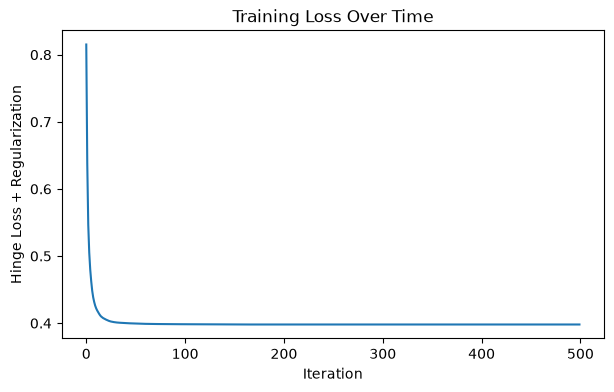

In [9]:
model = LinearSVM(learning_rate=0.001, lambda_param=0.01, n_iters=500)
model.fit(X_train_scaled, y_train)

plt.figure(figsize=(7, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Hinge Loss + Regularization')
plt.title('Training Loss Over Time')
plt.show()

During training, the model repeatedly checks each point against the margin condition and nudges `w` and `b` to reduce mistakes. As training progresses, fewer points violate the margin, so the loss generally decreases and the hyperplane settles into a wide-margin separator between the two classes.

## 8. Making Predictions

We use the trained weights to predict the class of each test point, based on the sign of `w·x + b`.

In [10]:
y_pred = model.predict(X_test_scaled)
y_pred[:10]

array([ 1., -1.,  1., -1., -1.,  1., -1., -1.,  1., -1.])

## 9. Model Evaluation

We compute accuracy manually, plus a simple confusion matrix.

In [11]:
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 83.75%


In [12]:
# Simple confusion matrix
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == -1) & (y_test == -1))
FP = np.sum((y_pred == 1) & (y_test == -1))
FN = np.sum((y_pred == -1) & (y_test == 1))

print(f"True Positives:  {TP}")
print(f"True Negatives:  {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")

True Positives:  16
True Negatives:  51
False Positives: 4
False Negatives: 9


## 10. Visualizing the Decision Boundary

Since we only used two features, we can plot the data, the decision boundary (`w·x + b = 0`), the margin lines (`w·x + b = ±1`), and highlight the support vectors — the training points closest to the boundary.

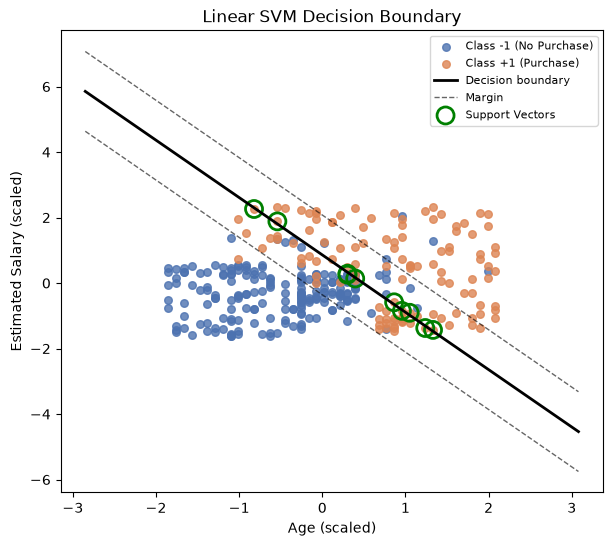

In [13]:
# distance of each training point to the hyperplane
distances = np.abs(model.decision_function(X_train_scaled)) / np.linalg.norm(model.w)
sv_idx = np.argsort(distances)[:10]  # 10 closest points = support vectors

x1_min, x1_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
xx = np.linspace(x1_min, x1_max, 50)

# w0*x + w1*y + b = c  ->  y = -(w0*x + b - c) / w1
yy_boundary = -(model.w[0] * xx + model.b) / model.w[1]
yy_margin_up = -(model.w[0] * xx + model.b - 1) / model.w[1]
yy_margin_down = -(model.w[0] * xx + model.b + 1) / model.w[1]

plt.figure(figsize=(7, 6))
plt.scatter(X_train_scaled[y_train == -1][:, 0], X_train_scaled[y_train == -1][:, 1],
            color='#4C72B0', label='Class -1 (No Purchase)', s=30, alpha=0.8)
plt.scatter(X_train_scaled[y_train == 1][:, 0], X_train_scaled[y_train == 1][:, 1],
            color='#DD8452', label='Class +1 (Purchase)', s=30, alpha=0.8)

plt.plot(xx, yy_boundary, 'k-', linewidth=2, label='Decision boundary')
plt.plot(xx, yy_margin_up, 'k--', linewidth=1, alpha=0.6, label='Margin')
plt.plot(xx, yy_margin_down, 'k--', linewidth=1, alpha=0.6)

plt.scatter(X_train_scaled[sv_idx][:, 0], X_train_scaled[sv_idx][:, 1],
            facecolors='none', edgecolors='green', s=150, linewidths=2, label='Support Vectors')

plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Linear SVM Decision Boundary')
plt.legend(loc='upper right', fontsize=8)
plt.show()

## 11. Conclusion

An **SVM** is a classifier that finds the hyperplane separating two classes with the **widest possible margin**, rather than just any separating line.

The **hinge loss** penalizes points that fall inside the margin or on the wrong side of it, while the **regularization term** keeps the weights small so the margin stays as wide as possible.

The **support vectors** are the training points closest to the boundary — they are the only points that actually determine where the hyperplane is drawn; the rest of the data could be removed without changing it.

Once trained, the model predicts the class of a new point simply by checking the **sign** of `w·x + b`.
